This model will combine the overhead RGB carbohydrate estimator, with the ingredient and mass estimator, to create a final carbohydrate prediction.

CPU data loadin block

In [ ]:
!pip install -q pandas numpy

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

tqdm.pandas()

Configuration

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

METADATA_CSV = Path(
    "/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/"
    "dish_carb_mass_ingredients_split_metadata.csv"
)

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_DIR:", DATASET_DIR)
print("METADATA_CSV:", METADATA_CSV)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PREP_DIR:", PREP_DIR)

DATASET_DIR: /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3
METADATA_CSV: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
OUTPUT_DIR: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion
PREP_DIR: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/prep_files


Loading metadata

In [ ]:
df = pd.read_csv(METADATA_CSV)

print("Loaded metadata from:", METADATA_CSV)
print("Shape before processing:", df.shape)
print("First 40 columns:")
print(df.columns.tolist()[:40])

display(df.head())

Loaded metadata from: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
Shape before processing: (3262, 205)
First 40 columns:
['dish_id', 'total_mass', 'total_carb', 'split', 'source_cafe', 'num_ingredients', 'ingredient_list_str', 'ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy', 'ingr_bread', 'ingr_broccoli', 'ingr_brown_rice', 'ingr_brown_sugar', 'ingr_brownies', 'ingr_brussels_sprouts', 'ingr_bulgur', 'ingr_butter', 'ingr_buttermilk', 'ingr_cabbage', 'ingr_caesar_dressing', 'ingr_caesar_salad', 'ingr_cantaloupe']


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_wheat_berry,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Validating correct load in

In [ ]:
required_cols = ["dish_id", "total_carb", "total_mass", "split", "source_cafe"]

missing_cols = [c for c in required_cols if c not in df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

ingredient_cols = [c for c in df.columns if c.startswith("ingr_")]

if len(ingredient_cols) == 0:
    raise ValueError("No ingredient columns found. Expected columns starting with 'ingr_'.")

print("Number of ingredient columns:", len(ingredient_cols))
print("First 20 ingredient columns:")
print(ingredient_cols[:20])

Number of ingredient columns: 198
First 20 ingredient columns:
['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy']


Creating image paths

In [ ]:
df["dish_id"] = df["dish_id"].astype(str).str.strip()

df["rgb_path"] = df["dish_id"].progress_apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].progress_apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())
print("Existing RGB images:", df["rgb_exists"].sum())

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

Missing RGB images: 0
Existing RGB images: 3262


Filtering for invalid images

In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except Exception:
        return -1


df["rgb_size"] = df["rgb_path"].progress_apply(file_size_or_minus1)

print("Empty or unreadable RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after RGB filtering:")
print(df["split"].value_counts(dropna=False))
print("Total remaining:", len(df))

display(df.head())

  0%|          | 0/3262 [00:00<?, ?it/s]

Empty or unreadable RGB files: 0

Remaining samples after RGB filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017


In [ ]:
df["total_carb"] = pd.to_numeric(df["total_carb"], errors="coerce")
df["total_mass"] = pd.to_numeric(df["total_mass"], errors="coerce")

for col in ingredient_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(np.float32)

df = df.dropna(subset=["total_carb", "total_mass"]).copy()

print("Remaining after numeric cleaning:", len(df))
print(df["split"].value_counts(dropna=False))

label_cardinality = df[ingredient_cols].sum(axis=1)

print("\nIngredient labels per dish:")
print(label_cardinality.describe())

print("\nCarbohydrate distribution:")
print(df["total_carb"].describe())

print("\nMass distribution:")
print(df["total_mass"].describe())

Remaining after numeric cleaning: 3262
split
train    2421
test      507
val       334
Name: count, dtype: int64

Ingredient labels per dish:
count    3262.000000
mean        7.312998
std         6.943369
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max        34.000000
dtype: float64

Carbohydrate distribution:
count    3262.000000
mean       19.386111
std        21.605225
min         0.000000
25%         6.171500
50%        15.360000
75%        27.532451
max       844.568604
Name: total_carb, dtype: float64

Mass distribution:
count    3262.000000
mean      214.980074
std       161.497428
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      3051.000000
Name: total_mass, dtype: float64


Splitting datasets

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

if len(train_df) == 0:
    raise ValueError("Train split is empty.")

if len(val_df) == 0:
    raise ValueError("Validation split is empty.")

if len(test_df) == 0:
    raise ValueError("Test split is empty.")

Train: 2421
Val:   334
Test:  507


Saving prepared data for GPU training

In [ ]:
train_csv = PREP_DIR / "train_model_21.csv"
val_csv   = PREP_DIR / "val_model_21.csv"
test_csv  = PREP_DIR / "test_model_21.csv"
full_csv  = PREP_DIR / "full_model_21.csv"
ingredient_cols_txt = PREP_DIR / "ingredient_columns.txt"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

with open(ingredient_cols_txt, "w") as f:
    for col in ingredient_cols:
        f.write(col + "\n")

print("Saved prepared files:")
print("Train CSV:        ", train_csv)
print("Validation CSV:   ", val_csv)
print("Test CSV:         ", test_csv)
print("Full CSV:         ", full_csv)
print("Ingredient columns:", ingredient_cols_txt)

Saved prepared files:
Train CSV:         /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/prep_files/train_model_21.csv
Validation CSV:    /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/prep_files/val_model_21.csv
Test CSV:          /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/prep_files/test_model_21.csv
Full CSV:          /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/prep_files/full_model_21.csv
Ingredient columns: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/prep_files/ingredient_columns.txt


SWITH TO GPU FOR MODEL TRAINING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q keras-hub keras-cv

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 43.6 MB/s eta 0:00:00


Configuration

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

EPOCHS = 200
LEARNING_RATE = 2e-4

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

CARB_BACKBONE_PRESET = "dinov2_large"
MASS_BACKBONE_PRESET = "dinov3_vit_base_lvd1689m"
INGR_BACKBONE_PRESET = "dinov2_base"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_model_21.csv"
val_csv   = PREP_DIR / "val_model_21.csv"
test_csv  = PREP_DIR / "test_model_21.csv"
ingredient_cols_txt = PREP_DIR / "ingredient_columns.txt"

MODEL3_WEIGHTS  = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage2.weights.h5")
MODEL18_WEIGHTS = Path("/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage2.weights.h5")
MODEL20_WEIGHTS = Path("/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/best_model_stage2.weights.h5")

print("OUTPUT_DIR:", OUTPUT_DIR)
print("MODEL3_WEIGHTS exists: ", MODEL3_WEIGHTS.exists())
print("MODEL18_WEIGHTS exists:", MODEL18_WEIGHTS.exists())
print("MODEL20_WEIGHTS exists:", MODEL20_WEIGHTS.exists())

OUTPUT_DIR: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion
MODEL3_WEIGHTS exists:  True
MODEL18_WEIGHTS exists: True
MODEL20_WEIGHTS exists: True


Loading prepared data

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

with open(ingredient_cols_txt, "r") as f:
    ingredient_cols = [line.strip() for line in f if line.strip()]

NUM_INGREDIENTS = len(ingredient_cols)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))
print("NUM_INGREDIENTS:", NUM_INGREDIENTS)

display(train_df.head())

Train: 2421
Val:   334
Test:  507
NUM_INGREDIENTS: 198


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,36.0,2.268,train,cafe1,1,olives,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,23.0,1.219,train,cafe1,1,mixed_greens,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,62.0,3.906,train,cafe1,1,olives,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,64.0,5.760,train,cafe1,1,brussels_sprouts,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,28.0,0.952,train,cafe1,1,celery,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].astype(str).values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

Creating datasets

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

train_eval_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:   ", batch_labels.shape)

RGB batch shape: (16, 224, 224, 3)
Labels shape:    (16,)


Building backbone models

In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

In [ ]:
def build_model3_carb_branch():
    rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        CARB_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        CARB_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization(name="carb_ln")(x)
        x = layers.GlobalAveragePooling1D(name="carb_token_pool")(x)
    else:
        x = layers.LayerNormalization(name="carb_ln")(x)
        x = layers.Flatten(name="carb_flatten")(x)

    x = layers.Dropout(0.3, name="carb_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="carb_dense_256")(x)
    x = layers.Dropout(0.3, name="carb_dropout_2")(x)
    feat = layers.Dense(64, activation="relu", name="carb_dense_64")(x)

    output = layers.Dense(1, activation="linear", name="carb_output")(feat)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="model3_carb_branch"
    )

    return model

In [ ]:
def build_model18_mass_branch():
    rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        MASS_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        MASS_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization(name="mass_ln")(x)
        x = layers.GlobalAveragePooling1D(name="mass_token_pool")(x)
    else:
        x = layers.LayerNormalization(name="mass_ln")(x)
        x = layers.Flatten(name="mass_flatten")(x)

    x = layers.Dropout(0.3, name="mass_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="mass_dense_256")(x)
    x = layers.Dropout(0.3, name="mass_dropout_2")(x)
    feat = layers.Dense(64, activation="relu", name="mass_dense_64")(x)

    output = layers.Dense(1, activation="linear", name="mass_output")(feat)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="model18_mass_branch"
    )

    return model

In [ ]:
def build_model20_ingredient_branch(num_ingredients):
    rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        INGR_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        INGR_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization(name="ingr_ln")(x)
        x = layers.GlobalAveragePooling1D(name="ingr_token_pool")(x)
    else:
        x = layers.LayerNormalization(name="ingr_ln")(x)
        x = layers.Flatten(name="ingr_flatten")(x)

    x = layers.Dropout(0.3, name="ingr_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="ingr_dense_256")(x)
    x = layers.Dropout(0.3, name="ingr_dropout_2")(x)

    feat = layers.Dense(128, activation="relu", name="ingr_dense_128")(x)
    x = layers.Dropout(0.2, name="ingr_dropout_3")(feat)

    output = layers.Dense(
        num_ingredients,
        activation="sigmoid",
        name="ingredient_output"
    )(x)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="model20_ingredient_branch"
    )

    return model

Loading saved weights for each branch

In [ ]:
carb_branch_model = build_model3_carb_branch()
mass_branch_model = build_model18_mass_branch()
ingredient_branch_model = build_model20_ingredient_branch(NUM_INGREDIENTS)

carb_branch_model.load_weights(str(MODEL3_WEIGHTS))
mass_branch_model.load_weights(str(MODEL18_WEIGHTS))
ingredient_branch_model.load_weights(str(MODEL20_WEIGHTS))

print("Loaded Model 3 V3 carbohydrate weights.")
print("Loaded Model 18 mass weights.")
print("Loaded Model 20 ingredient weights.")

100%|██████████| 782/782 [00:00<00:00, 1.59MB/s]


100%|██████████| 977/977 [00:00<00:00, 1.59MB/s]


100%|██████████| 1.14G/1.14G [00:22<00:00, 55.4MB/s]


100%|██████████| 1.13k/1.13k [00:00<00:00, 3.14MB/s]


100%|██████████| 978/978 [00:00<00:00, 2.55MB/s]


100%|██████████| 327M/327M [00:07<00:00, 47.1MB/s]


100%|██████████| 781/781 [00:00<00:00, 2.21MB/s]


100%|██████████| 977/977 [00:00<00:00, 2.42MB/s]


100%|██████████| 335M/335M [00:06<00:00, 53.3MB/s]


Loaded Model 3 V3 carbohydrate weights.
Loaded Model 18 mass weights.
Loaded Model 20 ingredient weights.


In [ ]:
carb_feature_model = keras.Model(
    inputs=carb_branch_model.input,
    outputs=[
        carb_branch_model.get_layer("carb_dense_64").output,
        carb_branch_model.output
    ],
    name="carb_feature_model"
)

mass_feature_model = keras.Model(
    inputs=mass_branch_model.input,
    outputs=[
        mass_branch_model.get_layer("mass_dense_64").output,
        mass_branch_model.output
    ],
    name="mass_feature_model"
)

ingredient_feature_model = keras.Model(
    inputs=ingredient_branch_model.input,
    outputs=[
        ingredient_branch_model.get_layer("ingr_dense_128").output,
        ingredient_branch_model.output
    ],
    name="ingredient_feature_model"
)

print("Created feature extractor models.")

Created feature extractor models.


In [ ]:
carb_feature_model.trainable = False
mass_feature_model.trainable = False
ingredient_feature_model.trainable = False

print("Carb feature model trainable:      ", carb_feature_model.trainable)
print("Mass feature model trainable:      ", mass_feature_model.trainable)
print("Ingredient feature model trainable:", ingredient_feature_model.trainable)

Carb feature model trainable:       False
Mass feature model trainable:       False
Ingredient feature model trainable: False


Building simple fusion head

In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

carb_feat, carb_pred = carb_feature_model({"rgb_input": rgb_input}, training=False)
mass_feat, mass_pred = mass_feature_model({"rgb_input": rgb_input}, training=False)
ingr_feat, ingr_pred = ingredient_feature_model({"rgb_input": rgb_input}, training=False)

fusion = layers.Concatenate(name="fusion_concat")([
    carb_feat,
    carb_pred,
    mass_feat,
    mass_pred,
    ingr_feat,
    ingr_pred
])

fusion = layers.Dense(256, activation="relu", name="fusion_dense_256")(fusion)
fusion = layers.Dropout(0.35, name="fusion_dropout_1")(fusion)

fusion = layers.Dense(128, activation="relu", name="fusion_dense_128")(fusion)
fusion = layers.Dropout(0.25, name="fusion_dropout_2")(fusion)

fusion = layers.Dense(64, activation="relu", name="fusion_dense_64")(fusion)
fusion = layers.Dropout(0.15, name="fusion_dropout_3")(fusion)

carb_output = layers.Dense(1, activation="linear", name="carb_output")(fusion)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=carb_output,
    name="model_21_carb_mass_ingredient_fusion_single_stage"
)

model.summary()

Model: "model_21_carb_mass_ingredient_fusion_single_stage"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_feature_model  │ [(None, 64),      │ 304,912,7… │ rgb_input[0][0]   │
│ (Functional)        │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_feature_model  │ [(None, 64),      │ 85,875,329 │ rgb_input[0][0]   │
│ (Functional)        │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ingredient_feature… │ [(None, 128),     │ 87,034,694 │ rgb_input[0][0]   │
│ (Functional)        │ (None, 198)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 456)       │          0 │ carb_feature_mod… │
│ (Concatenate)       │                   │            │ carb_feature_mod… │
│                     │                   │            │ mass_feature_mod… │
│                     │                   │            │ mass_feature_mod… │
│                     │                   │            │ ingredient_featu… │
│                     │                   │            │ ingredient_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_256    │ (None, 256)       │    116,992 │ fusion_concat[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_1    │ (None, 256)       │          0 │ fusion_dense_256… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_128    │ (None, 128)       │     32,896 │ fusion_dropout_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_2    │ (None, 128)       │          0 │ fusion_dense_128… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_64     │ (None, 64)        │      8,256 │ fusion_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_3    │ (None, 64)        │          0 │ fusion_dense_64[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_output (Dense) │ (None, 1)         │         65 │ fusion_dropout_3… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 477,981,001 (1.78 GB)

 Trainable params: 158,209 (618.00 KB)

 Non-trainable params: 477,822,792 (1.78 GB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ],
    jit_compile=False
)

In [ ]:
best_model_path = OUTPUT_DIR / "best_model_single_stage.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - loss: 695.3438 - mae: 12.9274 - mse: 695.3438 - rmse: 25.7811
Epoch 1: val_loss improved from None to 89.31972, saving model to /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/best_model_single_stage.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/best_model_single_stage.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 183s 939ms/step - loss: 395.5298 - mae: 10.6156 - mse: 395.5298 - rmse: 19.8879 - val_loss: 89.3197 - val_mae: 6.8878 - val_mse: 89.3197 - val_rmse: 9.4509 - learning_rate: 2.0000e-04
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 134.8091 - mae: 7.9986 - mse: 134.8091 - rmse: 11.6030
Epoch 2: val_loss improved from 89.31972 to 48.79942, saving model to /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/best_model_single_stage.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/

Evaluating on test set

In [ ]:
model.load_weights(str(best_model_path))

test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Single-stage test results:")
for k, v in test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 731ms/step - loss: 51.5119 - mae: 4.5335 - mse: 51.5119 - rmse: 7.1772
Single-stage test results:
loss: 51.5119
mae: 4.5335
mse: 51.5119
rmse: 7.1772


Plotting training and validation curves

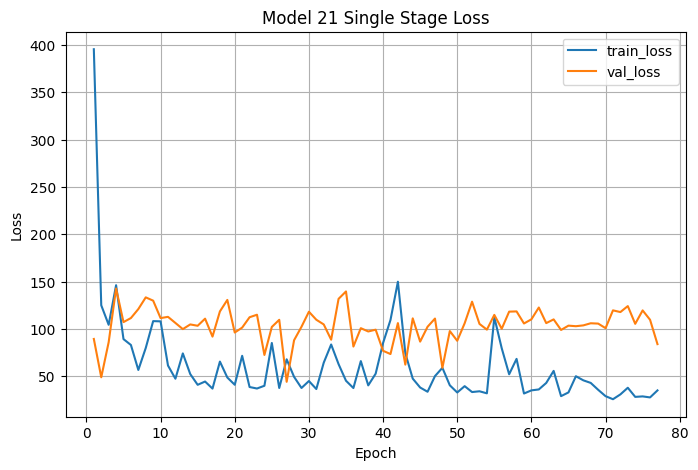

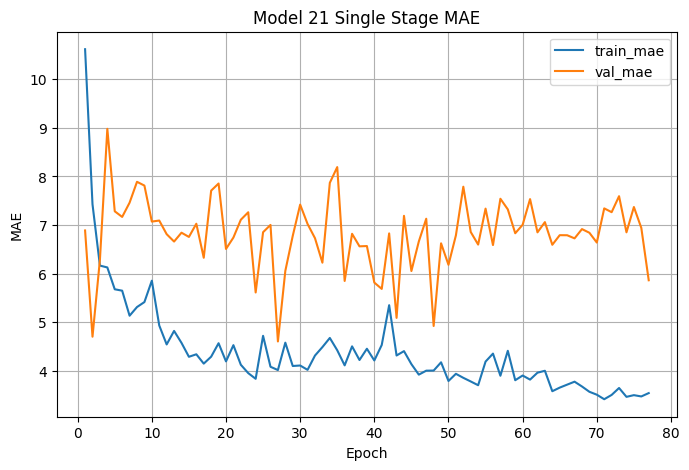

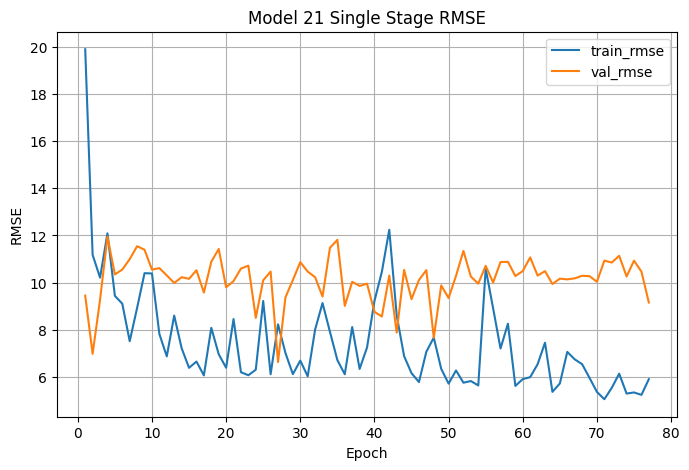

In [ ]:
def plot_history(history, title_prefix="Model 21 Single Stage"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["rmse"], label="train_rmse")
    plt.plot(epochs, hist["val_rmse"], label="val_rmse")
    plt.title(f"{title_prefix} RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history)

Saving test predictions

In [ ]:
model.load_weights(str(best_model_path))

test_eval_df = test_df.copy().reset_index(drop=True)

test_preds = model.predict(test_dataset, verbose=1).reshape(-1)

test_eval_df["prediction"] = test_preds
test_eval_df["abs_error"] = np.abs(test_eval_df["total_carb"] - test_eval_df["prediction"])
test_eval_df["signed_error"] = test_eval_df["prediction"] - test_eval_df["total_carb"]
test_eval_df["squared_error"] = test_eval_df["signed_error"] ** 2

pred_csv = OUTPUT_DIR / "test_predictions_single_stage.csv"
test_eval_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
display(test_eval_df.head())

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 413ms/step
Saved: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/test_predictions_single_stage.csv


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size,prediction,abs_error,signed_error,squared_error
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0.0,0.0,0.0,...,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259,13.719141,3.101141,3.101141,9.617076
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0.0,0.0,0.0,...,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804,1.383706,1.383706,1.383706,1.914642
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0.0,0.0,0.0,...,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501,1.287505,1.287505,1.287505,1.657669
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0.0,0.0,0.0,...,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780,3.032852,0.817148,-0.817148,0.667730
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0.0,0.0,0.0,...,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017,2.742920,2.742920,2.742920,7.523612


Metrics

In [ ]:
def compute_pmae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    mae = np.mean(np.abs(y_pred - y_true))
    mean_true = np.mean(y_true)

    return 100 * mae / mean_true


def build_metric_dict(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": float(mean_squared_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "pmae": float(compute_pmae(y_true, y_pred)),
        "mean_true_carb": float(np.mean(y_true)),
        "mean_pred_carb": float(np.mean(y_pred))
    }


test_metrics = build_metric_dict(
    test_eval_df["total_carb"].values,
    test_eval_df["prediction"].values
)

print("Test metrics:")
print(json.dumps(test_metrics, indent=2))

Test metrics:
{
  "mae": 4.533529281616211,
  "mse": 51.511878967285156,
  "rmse": 7.177177646351326,
  "r2": 0.8302897214889526,
  "pmae": 23.032018661499023,
  "mean_true_carb": 19.683595657348633,
  "mean_pred_carb": 18.734525680541992
}


In [ ]:
model.load_weights(str(best_model_path))

train_preds = model.predict(train_eval_dataset, verbose=1).reshape(-1)
val_preds   = model.predict(validation_dataset, verbose=1).reshape(-1)
test_preds  = model.predict(test_dataset, verbose=1).reshape(-1)

train_eval_df = train_df.copy().reset_index(drop=True)
val_eval_df   = val_df.copy().reset_index(drop=True)
test_eval_df  = test_df.copy().reset_index(drop=True)

train_eval_df["prediction"] = train_preds
val_eval_df["prediction"]   = val_preds
test_eval_df["prediction"]  = test_preds

for eval_df in [train_eval_df, val_eval_df, test_eval_df]:
    eval_df["abs_error"] = np.abs(eval_df["total_carb"] - eval_df["prediction"])
    eval_df["signed_error"] = eval_df["prediction"] - eval_df["total_carb"]
    eval_df["squared_error"] = eval_df["signed_error"] ** 2

train_metrics = build_metric_dict(train_eval_df["total_carb"].values, train_eval_df["prediction"].values)
val_metrics   = build_metric_dict(val_eval_df["total_carb"].values, val_eval_df["prediction"].values)
test_metrics  = build_metric_dict(test_eval_df["total_carb"].values, test_eval_df["prediction"].values)

train_predictions_path = OUTPUT_DIR / "train_predictions_single_stage.csv"
val_predictions_path   = OUTPUT_DIR / "val_predictions_single_stage.csv"
test_predictions_path  = OUTPUT_DIR / "test_predictions_single_stage.csv"

train_eval_df.to_csv(train_predictions_path, index=False)
val_eval_df.to_csv(val_predictions_path, index=False)
test_eval_df.to_csv(test_predictions_path, index=False)

summary = {
    "model_name": "Model 21 - Carb + Mass + Ingredient predicted fusion",
    "training_setup": "single_stage_frozen_pretrained_branches",
    "best_weights_path": str(best_model_path),
    "test_results": {k: float(v) for k, v in test_results.items()},
    "train_metrics": train_metrics,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
    "num_ingredient_features": int(NUM_INGREDIENTS),
    "carb_backbone": CARB_BACKBONE_PRESET,
    "mass_backbone": MASS_BACKBONE_PRESET,
    "ingredient_backbone": INGR_BACKBONE_PRESET,
    "epochs_run": len(history.history["loss"]),
    "best_val_loss": float(np.min(history.history["val_loss"])),
    "best_val_mae": float(np.min(history.history["val_mae"])),
    "best_val_rmse": float(np.min(history.history["val_rmse"]))
}

summary_path = OUTPUT_DIR / "model21_single_stage_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved train predictions to:", train_predictions_path)
print("Saved validation predictions to:", val_predictions_path)
print("Saved test predictions to:", test_predictions_path)
print("Saved summary to:", summary_path)

print(json.dumps(summary, indent=2))

152/152 ━━━━━━━━━━━━━━━━━━━━ 24s 158ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step
Saved train predictions to: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/train_predictions_single_stage.csv
Saved validation predictions to: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/val_predictions_single_stage.csv
Saved test predictions to: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/test_predictions_single_stage.csv
Saved summary to: /content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/model21_single_stage_summary.json
{
  "model_name": "Model 21 - Carb + Mass + Ingredient predicted fusion",
  "training_setup": "single_stage_frozen_pretrained_branches",
  "best_weights_path": "/content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/best_model_single_stage.weights.h5",
  "test_results": {
    "loss": 51.51187515258789,
   

Saving final model

In [ ]:
model.load_weights(str(best_model_path))

final_keras_path = OUTPUT_DIR / "final_model_single_stage.keras"
model.save(final_keras_path)

export_dir = OUTPUT_DIR / "saved_model_export_single_stage"
model.export(export_dir)

print("Saved final .keras model to:", final_keras_path)
print("Saved exported model to:", export_dir)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


Saved artifact at '/content/drive/MyDrive/Speciale/Models/Model_21_Carb_Mass_Ingredient_Fusion/saved_model_export_single_stage'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['rgb_input', TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='rgb_input')]]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133336479128592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479125904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479125520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479127440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479129168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479126096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479129552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479128784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133336479130320: TensorSpec(shape=(), dtype=t